# User Churn Prediction System - EDA Analysis

**Problem Statement:**

The goal of this analysis is to understand the factors influencing customer churn whether a customer leaves or stays with the company. Using customer demographics, account details, and service usage data, we’ll explore trends, detect patterns, and identify key drivers behind churn to support model building and retention strategies.

**Data Set Collection:**

DataSet Source : https://www.kaggle.com/datasets/blastchar/telco-customer-churn

This dataset contains 21 columns and 7043 rows of data.

**Required Packages:**

* Pandas
* Numpy
* Matplotlib.pyplot
* Seaborn
* Warnings Library


In [1]:
# importing libraries and data
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
%matplotlib inline
import warnings 
warnings.filterwarnings('ignore')

data_path = os.path.join(os.getcwd(), "data", "Telco-Customer-Churn.csv")

df = pd.read_csv(data_path)
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df.shape

(7043, 21)

**Dataset Information:**

* CustomerID : Unique identifier for each customer

* gender : Gender of the customer (Male / Female)

* SeniorCitizen : Indicates whether the customer is a senior citizen (1 = Yes, 0 = No)

* Partner : Whether the customer has a partner (Yes / No)

* Dependents : Whether the customer has dependents (Yes / No)

* tenure : Number of months the customer has stayed with the company

* PhoneService : Whether the customer has a phone service (Yes / No)

* MultipleLines : Whether the customer has multiple lines (Yes / No / No phone service)

* InternetService : Type of internet service (DSL / Fiber optic / No)

* OnlineSecurity : Whether the customer has online security (Yes / No / No internet service)

* OnlineBackup : Whether the customer has online backup (Yes / No / No internet service)

* DeviceProtection : Whether the customer has device protection (Yes / No / No internet service)

* TechSupport : Whether the customer has tech support (Yes / No / No internet service)

* StreamingTV : Whether the customer streams TV (Yes / No / No internet service)

* StreamingMovies : Whether the customer streams movies (Yes / No / No internet service)

* Contract : Type of customer contract (Month-to-month / One year / Two year)

* PaperlessBilling : Whether the customer uses paperless billing (Yes / No)

* PaymentMethod : Method of payment (Electronic check, Mailed check, Bank transfer, Credit card)

* MonthlyCharges : Amount charged per month

* TotalCharges : Total amount charged during the entire tenure

* Churn : Target variable — whether the customer has churned (Yes / No)



**Data Checks to Perform :**

* Check if any Missing Values
* Check if any Duplicates
* Check about Data types
* Check the Statictics of the Dataset


In [3]:
# Checking missing values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [4]:
# checking if any duplicates
df.duplicated().sum()

np.int64(0)

In [5]:
# Checking about data types
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
# checking  statistics
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


* SeniorCitizen: Only 16.2% of customers are senior citizens, indicating that the majority of the user base is younger.

* Tenure: The average tenure is around 32 months, with customers ranging from 0 to 72 months. The wide standard deviation (~24.5) suggests varied customer loyalty some churn early, while others stay for several years.

* MonthlyCharges: The average monthly charge is 
18.25 to $118.75, showing a broad distribution of service plans and pricing tiers.



**Feature Overview**

In [8]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical Columns:", cat_cols)
print("Numerical Columns:", num_cols)

Categorical Columns: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']
Numerical Columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges']


<Axes: xlabel='MonthlyCharges'>

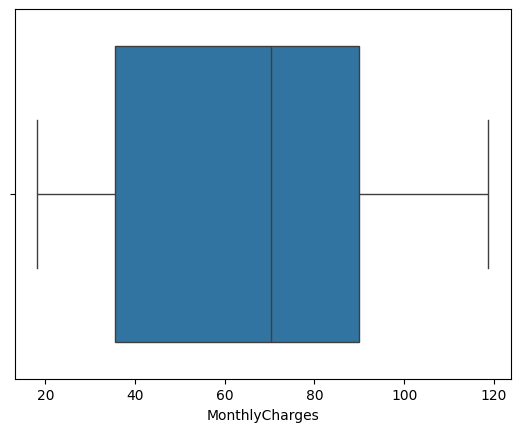

In [9]:
sns.boxplot(x=df['MonthlyCharges'])

**EDA Analysis**

**Univariate Anlysis:**

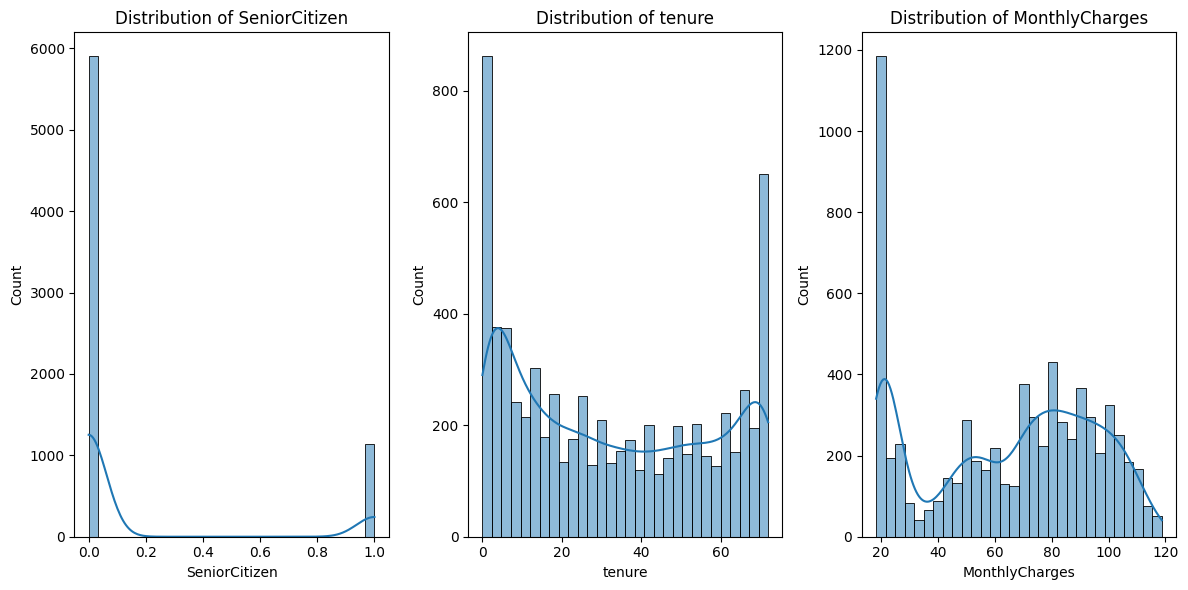

In [10]:
plt.figure(figsize=(12,6))
for i, col in enumerate(num_cols, 1):
    plt.subplot(1, len(num_cols), i)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()


* Most customers are not senior citizens; tenure shows a right-skewed pattern, meaning many customers are relatively new.
* MonthlyCharges displays a bimodal distribution, indicating two main service tiers — low-cost basic and high-cost premium users.

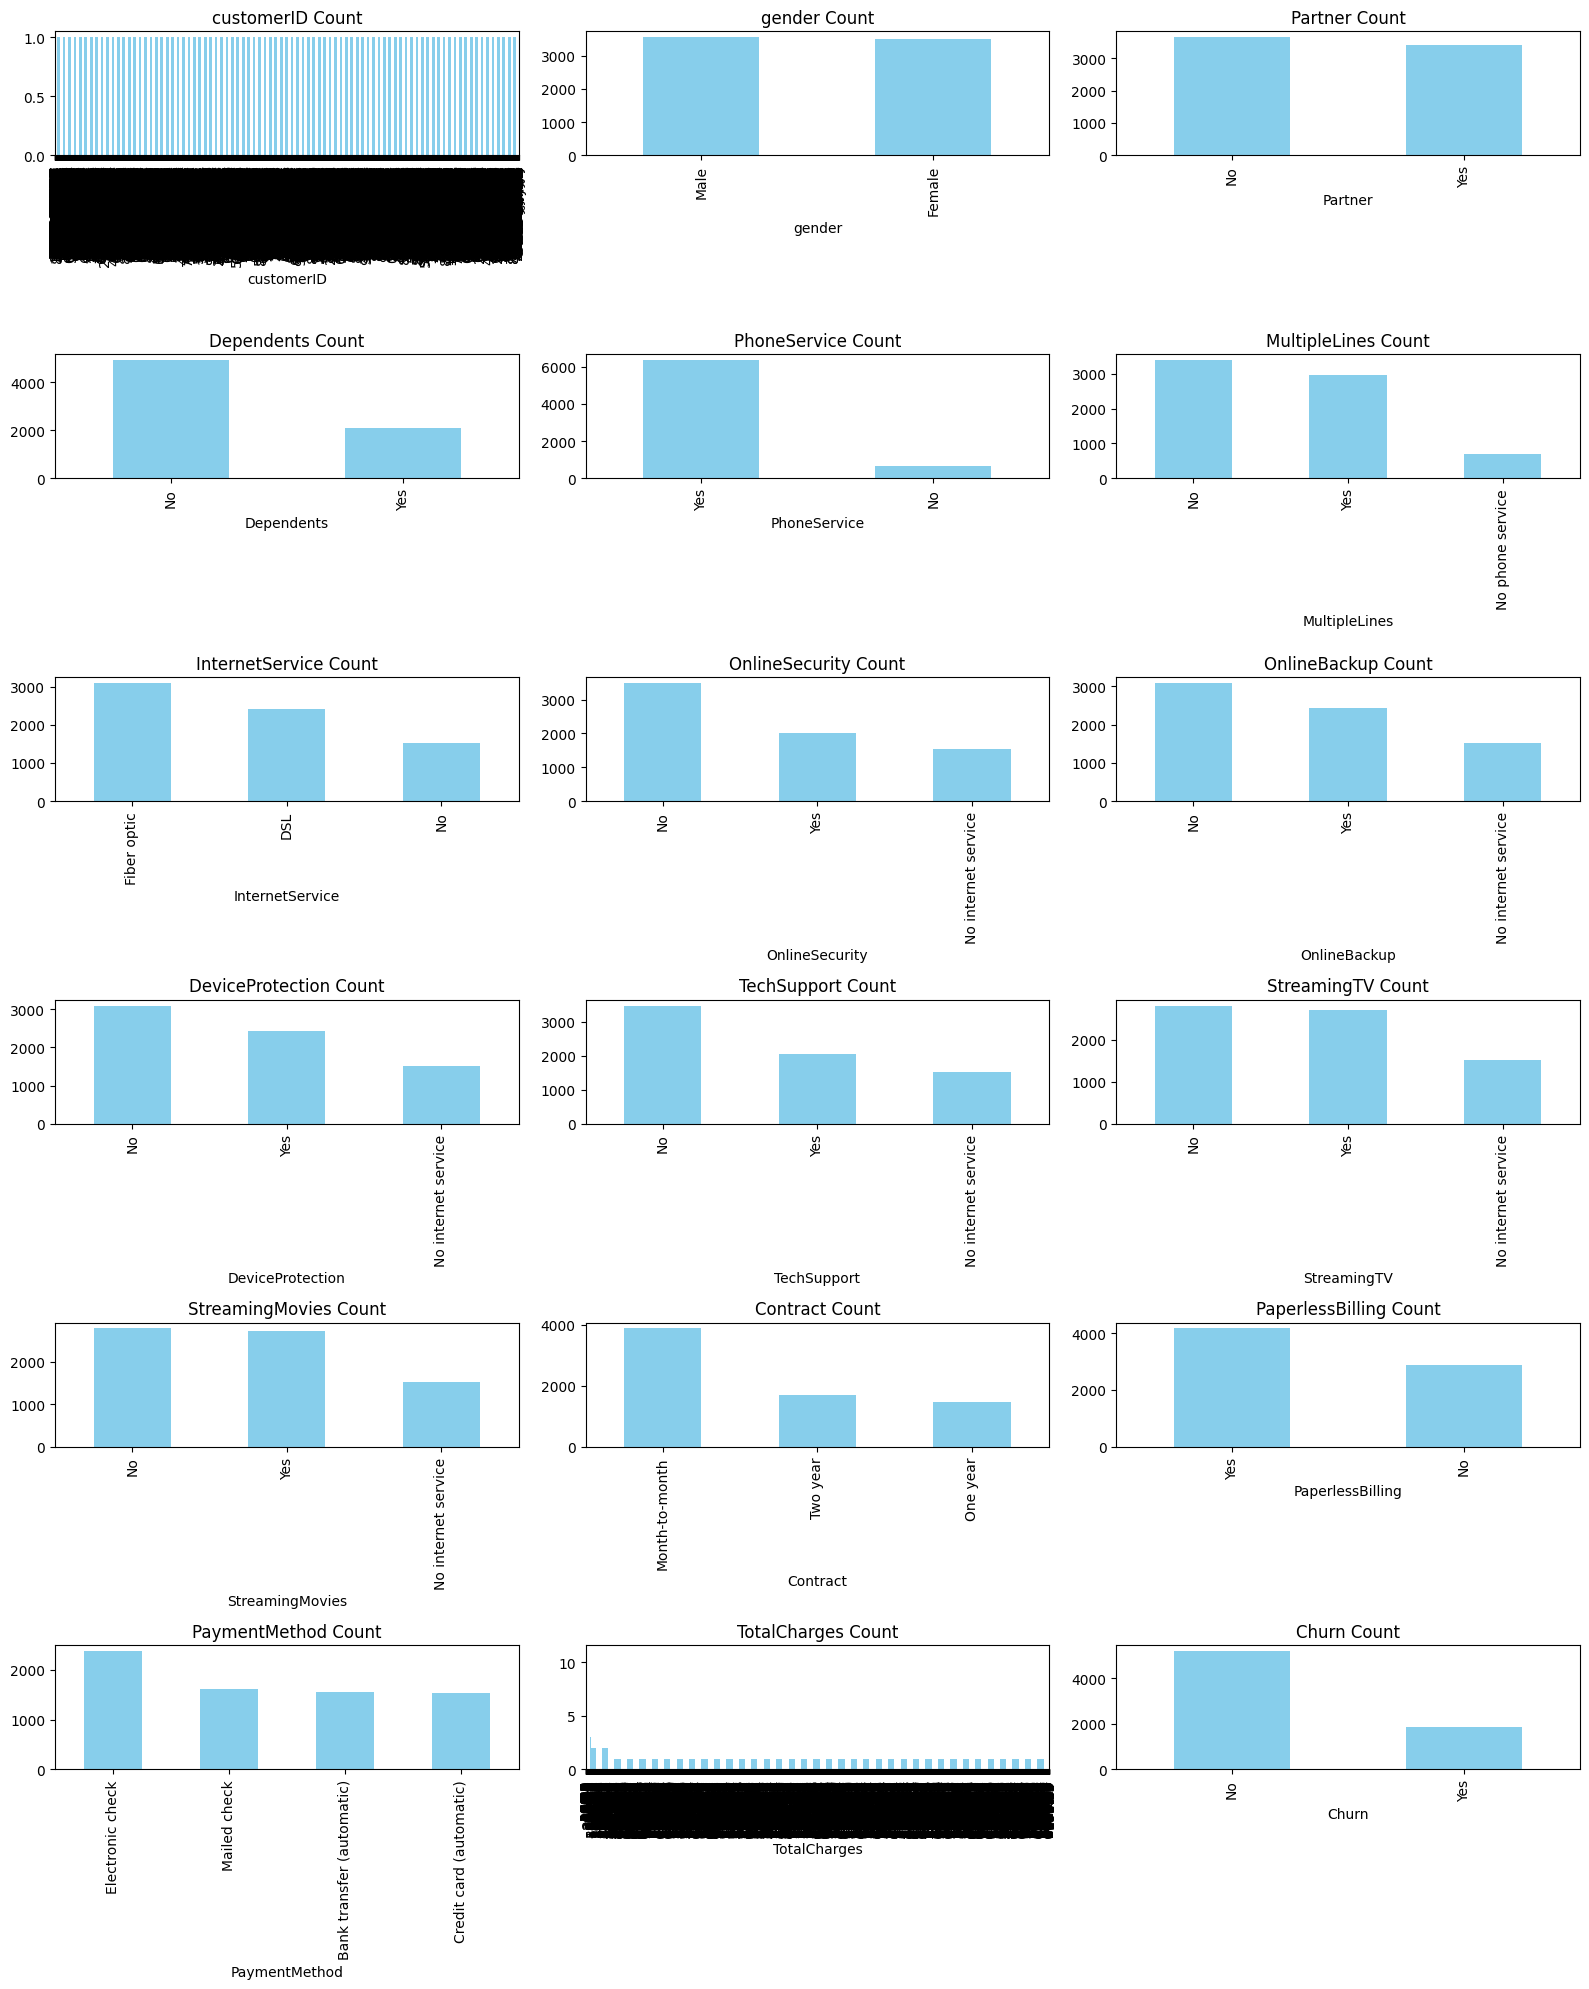

In [11]:
# categorical columns
plt.figure(figsize=(16,20))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(6, 3, i)
    df[col].value_counts().plot(kind='bar', color='skyblue')
    plt.title(f'{col} Count')
plt.tight_layout()
plt.show()


* Features like gender, Partner, and PhoneService are almost evenly distributed.

* Internet-related services show many “No” responses, suggesting underutilized optional add-ons.



**Bivariate Analysis:**

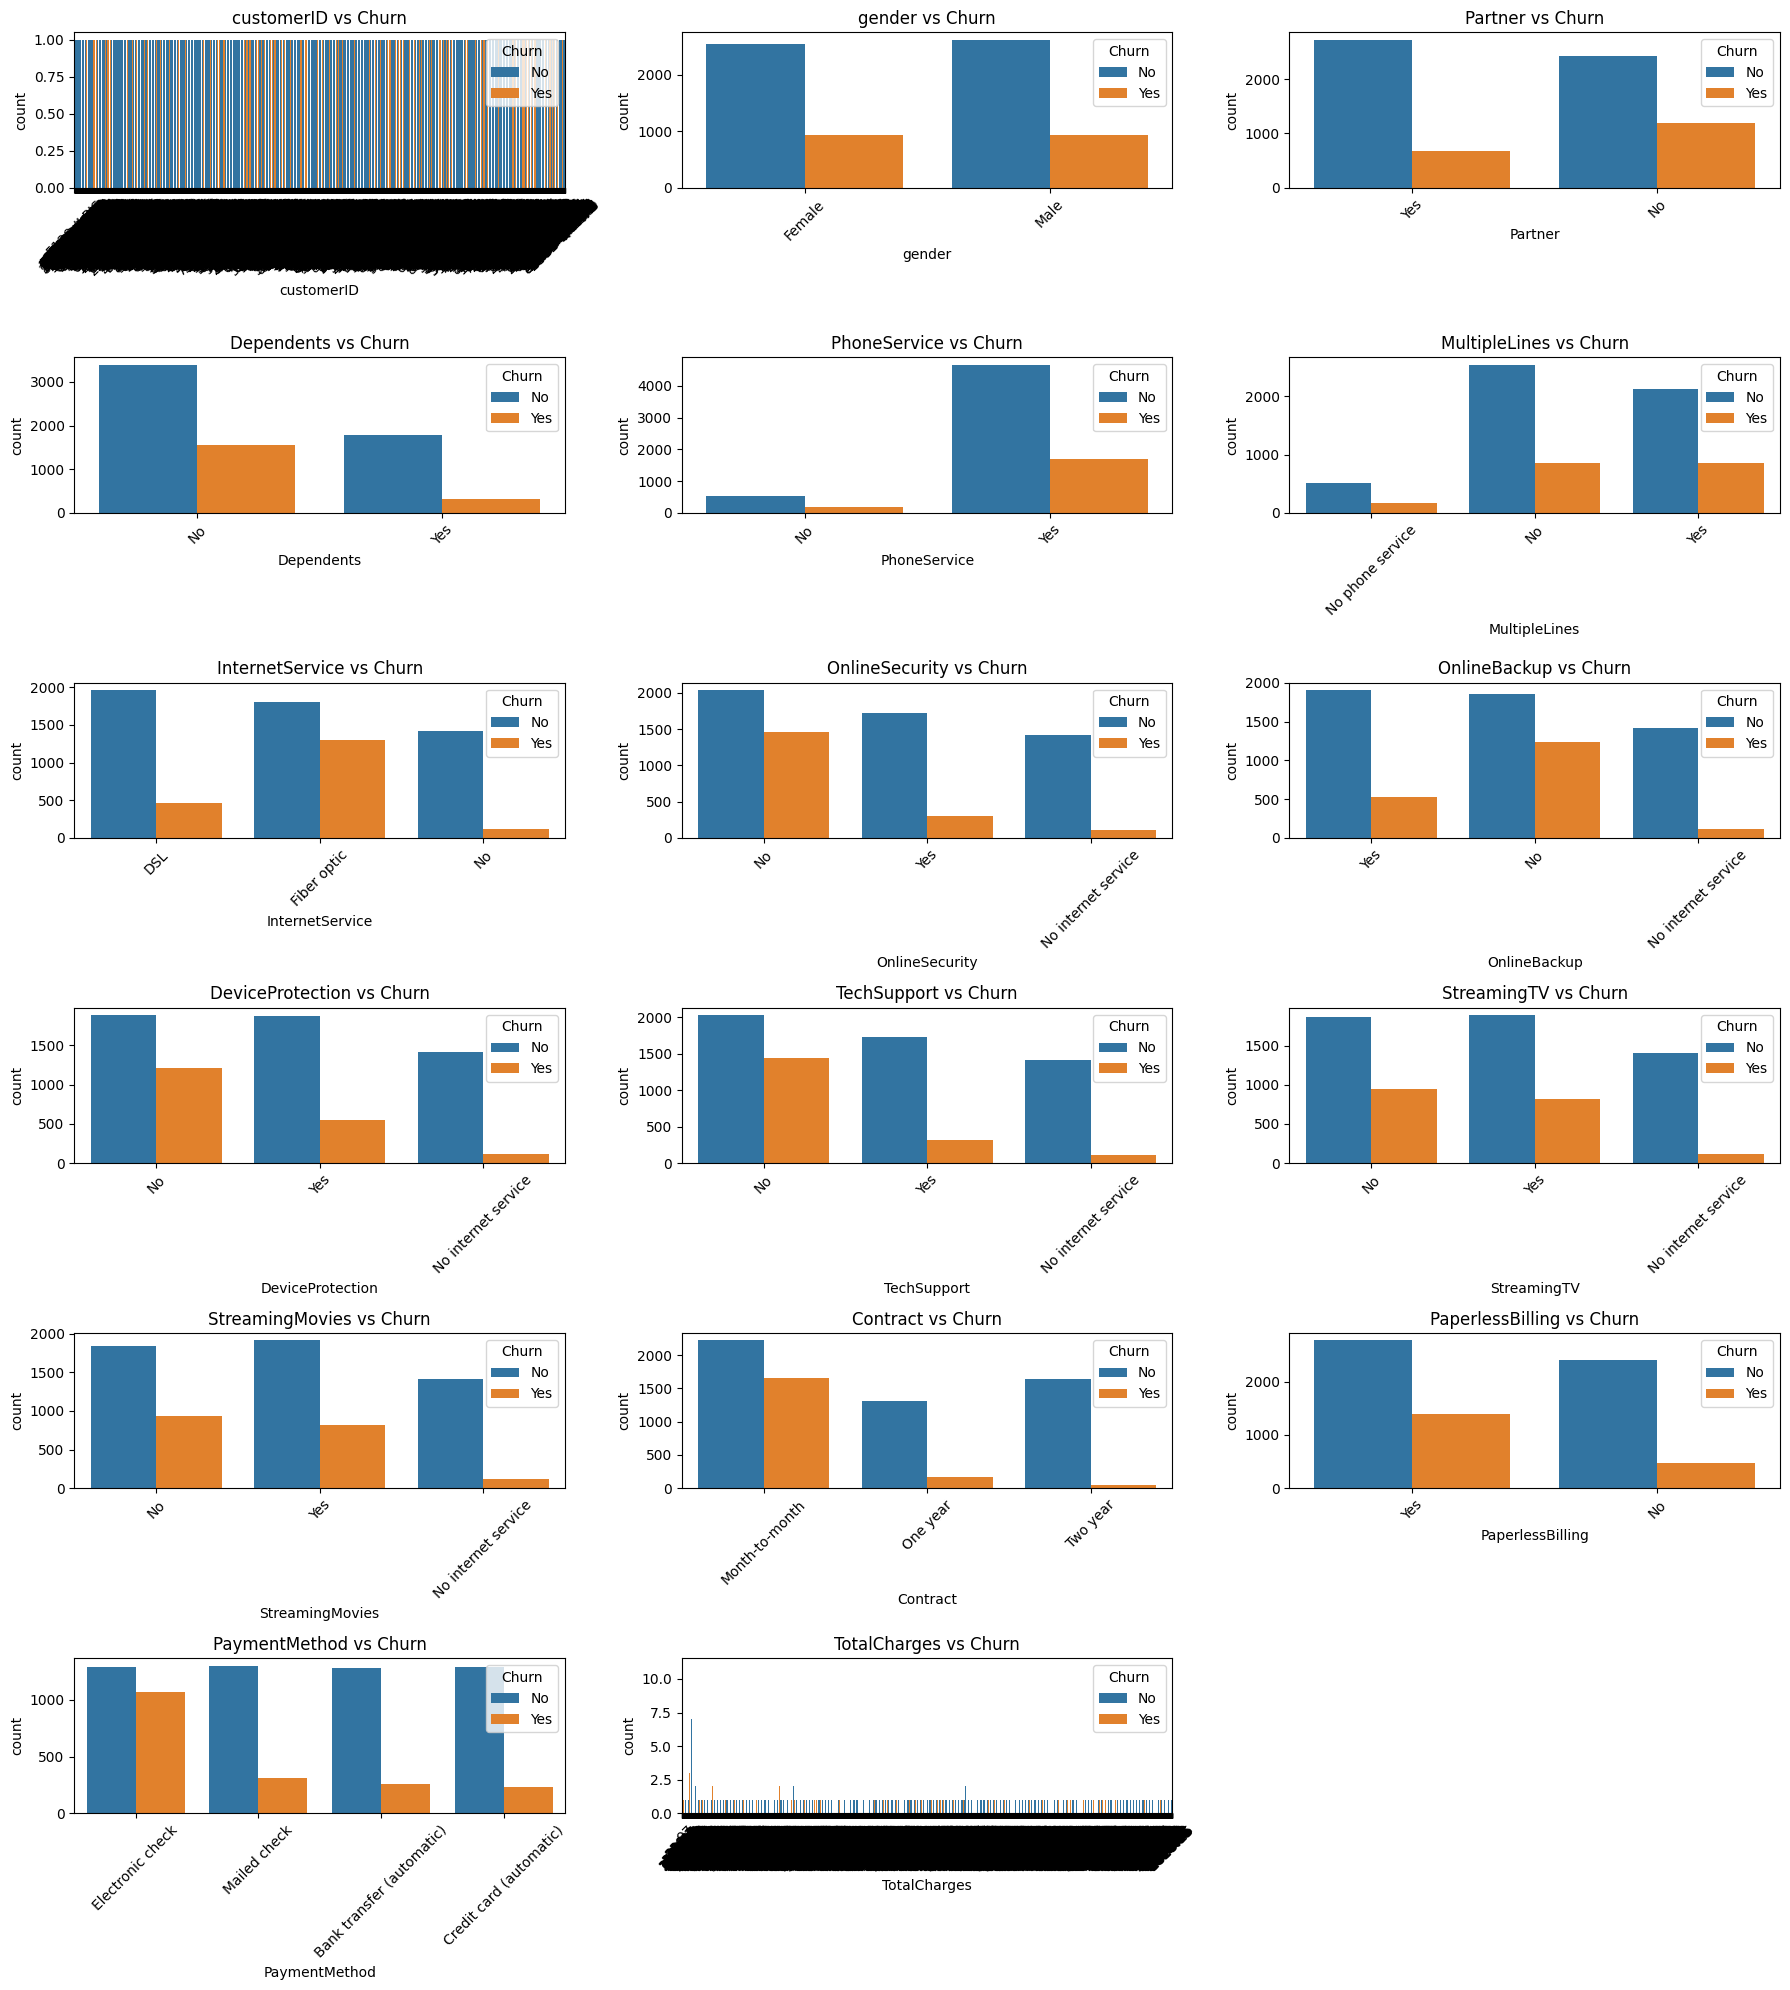

In [12]:
plt.figure(figsize=(18,20))
for i, col in enumerate(cat_cols[:-1], 1):
    plt.subplot(6, 3, i)
    sns.countplot(data=df, x=col, hue='Churn')
    plt.title(f'{col} vs Churn')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Bivariate analysis shows that customers with month-to-month contracts, higher monthly charges, and shorter tenure are far more likely to churn. Long-term contracts, automatic payments, and loyal tenure are strong indicators of customer retention.


**Numerical Features VS Churn**

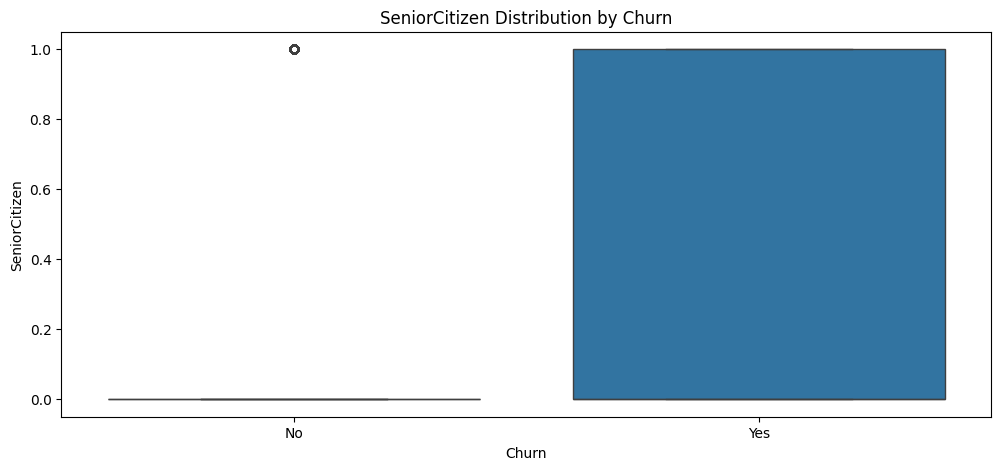

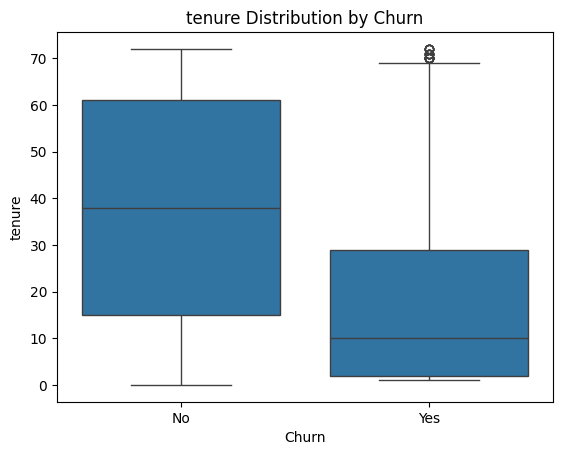

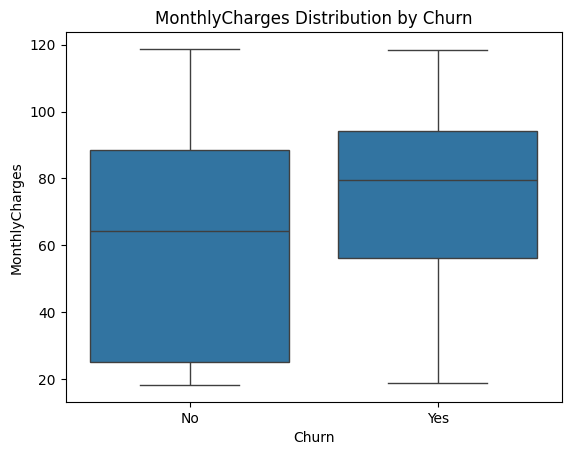

In [13]:
plt.figure(figsize=(12,5))
for col in num_cols:
    sns.boxplot(data=df, x='Churn', y=col)
    plt.title(f'{col} Distribution by Churn')
    plt.show()


* Senior citizens exhibit slightly higher churn rates, likely due to less tech adoption or service satisfaction issues.
* Churned customers tend to have shorter tenures, while long-term customers are more stable tenure strongly influences retention.
* Tenure and MonthlyCharges show a mild positive relationship customers who stay longer often pay higher monthly fees.


**Correlation Analysis :**

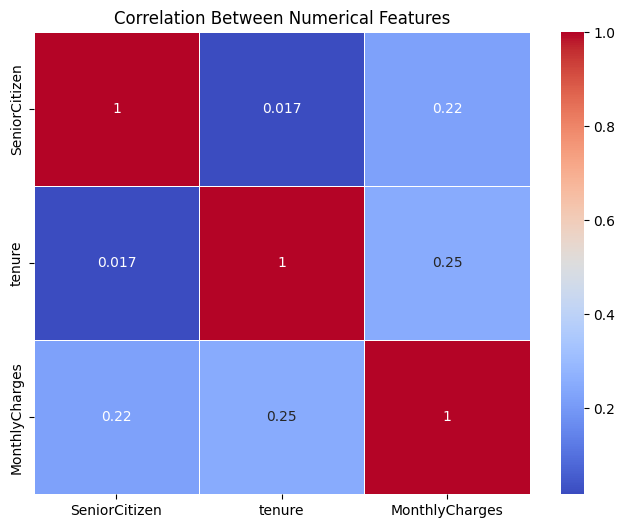

In [15]:
plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Between Numerical Features')
plt.show()

* Weak correlations among numerical features imply multicollinearity isn’t a major concern.

* Tenure and MonthlyCharges show a mild positive relationship  customers who stay longer often pay higher monthly fees.



**Customer Segmenatation Analysis**

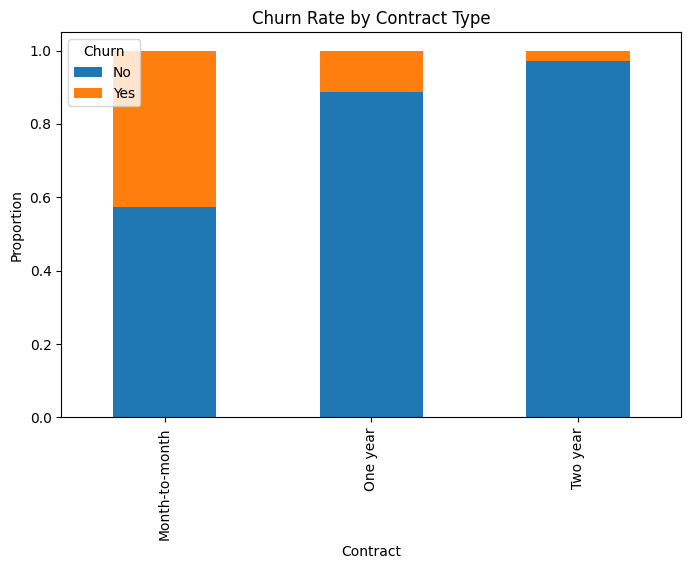

In [16]:
contract_churn = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack()
contract_churn.plot(kind='bar', stacked=True, figsize=(8,5), color=['#1f77b4','#ff7f0e'])
plt.title('Churn Rate by Contract Type')
plt.ylabel('Proportion')
plt.show()

* Month-to-month customers show the highest churn proportion, while two-year contracts retain most users.

* Longer commitments clearly reduce churn risk, highlighting the impact of contract structure on customer loyalty.

**Conclusion :**

* Customers with short tenure and flexible month-to-month contracts are at the highest risk of churn.

* Offering discounts or loyalty benefits for long-term contracts could significantly reduce churn and improve retention.